# K 近邻法（KNN）手搓复现

参考《统计学习方法》第 3 章。全程只用 `numpy` / `pandas` / `matplotlib`，不调用 `sklearn`。

KNN 的三要素：**距离度量**、**k 值选择**、**分类决策规则**。本 notebook 依次手写：

1. 数据读取、标准化、训练/测试集划分
2. $L_p$ 距离（单点版 + 向量化距离矩阵版）
3. KNN 分类器：多数表决 / 距离加权表决，暴力搜索 / kd 树搜索两种后端
4. **kd 树**的构造与 k 近邻搜索（书中算法 3.2、3.3）
5. 手写 K 折交叉验证选 k（只用训练集，避免用测试集调参造成信息泄漏）
6. 评估指标与二维决策边界可视化

### 数据集准备

In [1]:
import heapq
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.font_manager import FontProperties

def _resolve_font(size: int = 10):
    """解析可用中文字体"""
    candidates = [
        Path("/System/Library/Fonts/PingFang.ttc"),
        Path("/System/Library/Fonts/Hiragino Sans GB.ttc"),
        Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return FontProperties(fname=str(candidate), size=size)
    return FontProperties(size=size)

fontProps = _resolve_font(11)
plt.rcParams["axes.unicode_minus"] = False

In [2]:
def load_dataset(csv_path: str, label_col: str, drop_cols=None):
    """
    读取银行贷款数据集，返回特征矩阵 X 和标签向量 y
    label_col: 作为分类标签的列名（这里用 Personal.Loan，即是否接受个人贷款）
    drop_cols: 不作为特征使用的列（ID、ZIP.Code 这种编号类字段，对距离计算没有意义）
    """
    df = pd.read_csv(csv_path)
    if drop_cols:
        df = df.drop(columns=drop_cols)

    y = df[label_col].to_numpy()
    features = df.drop(columns=[label_col])
    return features.to_numpy(dtype=float), y, features.columns.tolist()

X, y, feature_names = load_dataset(
    "../data/bankloan.csv",
    label_col="Personal.Loan",
    drop_cols=["ID", "ZIP.Code"],
)

print("特征:", feature_names)
print("样本数:", X.shape[0], "特征数:", X.shape[1])
print("各类样本数 [0, 1]:", np.bincount(y))

特征: ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities.Account', 'CD.Account', 'Online', 'CreditCard']
样本数: 5000 特征数: 11
各类样本数 [0, 1]: [4520  480]


### 特征标准化

KNN 依赖样本间的距离。如果特征量纲差异很大（Income 是几十到几百，Family 只有 1–4），量纲大的特征会主导距离。
所以先做 z-score 标准化：$x' = (x-\mu)/\sigma$。**$\mu,\sigma$ 只能用训练集计算**，测试集复用同一套参数。

In [3]:
def standardize(X, mean=None, std=None):
    """
    z-score 标准化。不传 mean/std 时用 X 自己计算（训练集）；
    传入训练集的 mean/std 则用同一套参数标准化测试集，避免数据泄漏。
    """
    if mean is None:
        mean = X.mean(axis=0)
    if std is None:
        std = X.std(axis=0)
        std = np.where(std == 0, 1.0, std)  # 防止常数列除 0
    return (X - mean) / std, mean, std

### 划分训练集 / 测试集

手写**分层**划分：正类只占约 10%，纯随机划分可能让测试集里的正类比例偏离总体，所以按类别分别打乱、分别切分。

In [4]:
def train_test_split(X, y, test_ratio=0.2, seed=42):
    """分层划分训练集和测试集，每个类别按相同比例切出测试样本"""
    rng = np.random.default_rng(seed)
    test_idx = []
    for c in np.unique(y):
        idx_c = rng.permutation(np.flatnonzero(y == c))
        test_idx.extend(idx_c[: int(round(len(idx_c) * test_ratio))])
    test_mask = np.zeros(len(y), dtype=bool)
    test_mask[test_idx] = True
    return X[~test_mask], X[test_mask], y[~test_mask], y[test_mask]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_ratio=0.2, seed=42)

X_train, mean_, std_ = standardize(X_train_raw)
X_test, _, _ = standardize(X_test_raw, mean=mean_, std=std_)

print("训练集:", X_train.shape, "正类占比 %.3f" % y_train.mean())
print("测试集:", X_test.shape, "正类占比 %.3f" % y_test.mean())

训练集: (4000, 11) 正类占比 0.096
测试集: (1000, 11) 正类占比 0.096


### 距离度量

书中定义的 $L_p$ 距离：

$$L_p(x_i, x_j) = \Big(\sum_{l=1}^{n} |x_i^{(l)} - x_j^{(l)}|^p\Big)^{1/p}$$

- $p=2$：欧氏距离；$p=1$：曼哈顿距离；$p=\infty$：各坐标差的最大值。

先写一个单点对单点的版本（最直白，kd 树里会用到），再写一个**向量化的距离矩阵**版本，给暴力搜索用。
欧氏距离的矩阵版用了展开式 $\|a-b\|^2 = \|a\|^2 + \|b\|^2 - 2a^\top b$，只需一次矩阵乘法，
不必构造 `(n_test, n_train, n_features)` 的三维中间数组，内存从 $O(mnd)$ 降到 $O(mn)$。

In [5]:
def lp_distance(x1, x2, p=2):
    """单个样本对单个样本的 Lp 距离"""
    diff = np.abs(x1 - x2)
    if p == np.inf:
        return diff.max()
    return np.sum(diff ** p) ** (1.0 / p)

def pairwise_distances(A, B, p=2):
    """
    A: (m, d), B: (n, d)  ->  距离矩阵 D: (m, n)，D[i, j] = Lp(A[i], B[j])
    """
    if p == 2:
        sq = (A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None, :] - 2 * A @ B.T
        return np.sqrt(np.maximum(sq, 0))  # 浮点误差可能产生极小的负数
    # 其他 p 按块计算，控制三维中间数组的大小
    D = np.empty((A.shape[0], B.shape[0]))
    step = max(1, 2_000_000 // (B.shape[0] * A.shape[1]))
    for s in range(0, A.shape[0], step):
        diff = np.abs(A[s:s + step, None, :] - B[None, :, :])
        D[s:s + step] = diff.max(-1) if p == np.inf else (diff ** p).sum(-1) ** (1.0 / p)
    return D

# 校验：矩阵版与单点版结果一致
for p in (1, 2, 3, np.inf):
    D = pairwise_distances(X_test[:5], X_train[:7], p=p)
    D_ref = np.array([[lp_distance(a, b, p) for b in X_train[:7]] for a in X_test[:5]])
    print(f"p={p}: 最大误差 {np.abs(D - D_ref).max():.2e}")

p=1: 最大误差 0.00e+00
p=2: 最大误差 8.88e-16
p=3: 最大误差 0.00e+00
p=inf: 最大误差 0.00e+00


### kd 树

暴力搜索每次预测都要和全部 $N$ 个训练样本算距离。kd 树把 $k$ 维空间递归地二分，搜索时可以**剪掉**不可能包含近邻的子树。

**构造（算法 3.2）**：在深度 $j$ 的结点选坐标轴 $l = j \bmod k$，以该轴上的**中位数**样本作为切分点放在结点上，
小于它的去左子树，大于等于的去右子树，递归直到子区域没有样本。

**k 近邻搜索（算法 3.3 推广到 k 个）**：

1. 从根出发，按切分轴比较，先递归进入目标点所在的一侧（"近侧"）；
2. 回退时把当前结点加入候选集。候选集用**大小为 k 的最大堆**维护，堆顶是当前第 k 近的距离 $r$；
3. 如果目标点到切分超平面的距离 $|x^{(l)} - s^{(l)}| < r$（或候选集还没满 k 个），说明以目标点为球心、半径 $r$ 的超球与另一侧相交，
   需要再去"远侧"子树搜索；否则整棵远侧子树直接剪掉。

对任意 $L_p$ 距离都有 $|x^{(l)} - s^{(l)}| \le L_p(x, s)$，所以这个剪枝条件对 $p=1,2,\infty$ 都成立。

In [6]:
class KDNode:
    __slots__ = ("idx", "axis", "left", "right")

    def __init__(self, idx, axis, left=None, right=None):
        self.idx = idx      # 切分点在训练集中的下标
        self.axis = axis    # 切分轴
        self.left = left
        self.right = right


class KDTree:
    def __init__(self, X, p=2):
        self.X = np.asarray(X, dtype=float)
        self.p = p
        self.n_features = self.X.shape[1]
        self.root = self._build(np.arange(len(self.X)), depth=0)

    def _build(self, indices, depth):
        """算法 3.2：递归构造平衡 kd 树"""
        if len(indices) == 0:
            return None
        axis = depth % self.n_features
        # 按当前轴排序，取中位数位置的样本做切分点
        order = indices[np.argsort(self.X[indices, axis], kind="stable")]
        mid = len(order) // 2
        return KDNode(
            idx=order[mid],
            axis=axis,
            left=self._build(order[:mid], depth + 1),
            right=self._build(order[mid + 1:], depth + 1),
        )

    def query(self, x, k=1):
        """
        算法 3.3（推广到 k 近邻）：返回 (距离数组, 下标数组)，按距离升序。
        同时记录访问过的结点数 self.last_visited，用来观察剪枝效果。
        """
        heap = []  # 存 (-距离, -下标)，Python 的 heapq 是最小堆，取负号变成最大堆
        self.last_visited = 0

        def search(node):
            if node is None:
                return
            self.last_visited += 1
            s = self.X[node.idx]
            diff = x[node.axis] - s[node.axis]
            near, far = (node.left, node.right) if diff < 0 else (node.right, node.left)

            # 1. 先深入目标点所在的一侧
            search(near)

            # 2. 回退：用当前结点更新候选集
            d = lp_distance(x, s, self.p)
            item = (-d, -node.idx)  # 距离相同时优先保留下标小的，和暴力搜索的稳定排序一致
            if len(heap) < k:
                heapq.heappush(heap, item)
            elif item > heap[0]:
                heapq.heapreplace(heap, item)

            # 3. 超球与切分超平面相交，才需要搜索另一侧
            if len(heap) < k or abs(diff) <= -heap[0][0]:
                search(far)

        search(self.root)
        result = sorted((-nd, -ni) for nd, ni in heap)
        dists = np.array([r[0] for r in result])
        idxs = np.array([r[1] for r in result], dtype=int)
        return dists, idxs

用书中例 3.2 的数据集验证：$T=\{(2,3),(5,4),(9,6),(4,7),(8,1),(7,2)\}$，书中构造出的根结点是 $(7,2)$，
左子树根 $(5,4)$，右子树根 $(9,6)$。

In [7]:
T = np.array([[2, 3], [5, 4], [9, 6], [4, 7], [8, 1], [7, 2]], dtype=float)
tree = KDTree(T)

def print_kdtree(node, data, depth=0, prefix="根"):
    if node is None:
        return
    print("    " * depth + f"{prefix}: {tuple(data[node.idx].astype(int).tolist())}  (按 x{node.axis + 1} 切分)")
    print_kdtree(node.left, data, depth + 1, "左")
    print_kdtree(node.right, data, depth + 1, "右")

print_kdtree(tree.root, T)

x_query = np.array([3.0, 4.5])
d, i = tree.query(x_query, k=2)
print("\n目标点", x_query, "的 2 个近邻:", [tuple(T[j].astype(int).tolist()) for j in i], "距离:", np.round(d, 4))

根: (7, 2)  (按 x1 切分)
    左: (5, 4)  (按 x2 切分)
        左: (2, 3)  (按 x1 切分)
        右: (4, 7)  (按 x1 切分)
    右: (9, 6)  (按 x2 切分)
        左: (8, 1)  (按 x1 切分)

目标点 [3.  4.5] 的 2 个近邻: [(2, 3), (5, 4)] 距离: [1.8028 2.0616]


### KNN 核心算法

预测流程：

1. 找到训练集中与 $x$ 最近的 $k$ 个点，记为 $N_k(x)$（暴力搜索或 kd 树）；
2. 分类决策：
   - **多数表决**（书中式 3.1）：$y = \arg\max_{c_j} \sum_{x_i \in N_k(x)} I(y_i = c_j)$，等价于经验风险最小化；
   - **距离加权表决**：每个近邻的票数为 $1/d_i$，越近的邻居话语权越大。若有距离为 0 的近邻，就只看这些完全重合的点。

`predict_proba` 返回各类别的（加权）票数占比，可以用来调分类阈值。

In [8]:
class KNNClassifier:
    """
    手写 K 近邻分类器
    k:         近邻个数
    p:         Lp 距离的 p（1 曼哈顿，2 欧氏，np.inf 切比雪夫）
    weights:   'uniform' 多数表决 / 'distance' 距离加权表决
    algorithm: 'brute' 暴力搜索（向量化） / 'kd_tree' kd 树搜索
    """

    def __init__(self, k=5, p=2, weights="uniform", algorithm="brute"):
        assert weights in ("uniform", "distance")
        assert algorithm in ("brute", "kd_tree")
        self.k, self.p, self.weights, self.algorithm = k, p, weights, algorithm

    def fit(self, X_train, y_train):
        """KNN 是惰性学习：fit 只保存训练数据（kd 树模式下顺便建树）"""
        self.X_train = np.asarray(X_train, dtype=float)
        self.y_train = np.asarray(y_train)
        self.classes_ = np.unique(self.y_train)
        self.y_encoded = np.searchsorted(self.classes_, self.y_train)  # 标签映射到 0..C-1
        if self.algorithm == "kd_tree":
            self.tree_ = KDTree(self.X_train, p=self.p)
        return self

    def kneighbors(self, X):
        """返回每个样本的 k 个近邻 (距离矩阵, 下标矩阵)，形状都是 (n_samples, k)"""
        X = np.asarray(X, dtype=float)
        k = min(self.k, len(self.X_train))
        if self.algorithm == "kd_tree":
            res = [self.tree_.query(x, k) for x in X]
            return np.array([r[0] for r in res]), np.array([r[1] for r in res])

        dists, idxs = [], []
        for s in range(0, len(X), 1000):  # 分批计算，避免测试样本很多时距离矩阵占用过多内存
            D = pairwise_distances(X[s:s + 1000], self.X_train, self.p)
            # 稳定排序：距离相同时下标小的排在前面，保证结果可复现、且与 kd 树一致
            idx = np.argsort(D, axis=1, kind="stable")[:, :k]
            dists.append(np.take_along_axis(D, idx, axis=1))
            idxs.append(idx)
        return np.vstack(dists), np.vstack(idxs)

    def _vote_weights(self, dists):
        if self.weights == "uniform":
            return np.ones_like(dists)
        with np.errstate(divide="ignore"):
            w = 1.0 / dists
        exact = np.isinf(w)
        rows = exact.any(axis=1)
        w[rows] = exact[rows].astype(float)  # 有完全重合的点时只让它们投票
        return w

    def predict_proba(self, X):
        dists, idx = self.kneighbors(X)
        w = self._vote_weights(dists)
        labels = self.y_encoded[idx]
        votes = np.zeros((len(idx), len(self.classes_)))
        for c in range(len(self.classes_)):
            votes[:, c] = (w * (labels == c)).sum(axis=1)
        return votes / votes.sum(axis=1, keepdims=True)

    def predict(self, X):
        # 票数相同时 argmax 取第一个类别
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

### 验证：暴力搜索 vs kd 树

两种搜索方式找到的近邻距离必须完全一致，预测结果也应一致。顺便对比耗时和 kd 树访问的结点数。

In [9]:
n_check = 200
for p in (1, 2):
    brute = KNNClassifier(k=5, p=p, algorithm="brute").fit(X_train, y_train)
    kd = KNNClassifier(k=5, p=p, algorithm="kd_tree").fit(X_train, y_train)

    t0 = time.perf_counter(); d_b, i_b = brute.kneighbors(X_test[:n_check]); t_b = time.perf_counter() - t0
    t0 = time.perf_counter(); d_k, i_k = kd.kneighbors(X_test[:n_check]); t_k = time.perf_counter() - t0

    same_pred = np.mean(brute.predict(X_test[:n_check]) == kd.predict(X_test[:n_check]))
    print(f"p={p}: 近邻距离一致={np.allclose(d_b, d_k)}, 预测一致率={same_pred:.3f}, "
          f"暴力 {t_b * 1000:.1f} ms, kd 树 {t_k * 1000:.1f} ms")

p=1: 近邻距离一致=True, 预测一致率=1.000, 暴力 214.5 ms, kd 树 2016.4 ms
p=2: 近邻距离一致=True, 预测一致率=1.000, 暴力 50.3 ms, kd 树 735.1 ms


kd 树在这里反而更慢，原因有两个：一是它是纯 Python 递归，而暴力搜索是 numpy 矩阵运算；
二是**维度灾难**：11 维空间里超球几乎总会和切分超平面相交，剪枝很少生效。
书中也提到 kd 树更适合训练样本数远大于维数的情形。下面统计搜索一个点平均访问多少个结点来直观看出这一点：

In [10]:
rng = np.random.default_rng(0)
N = 4000
print(f"训练样本数 N = {N}，统计 1 近邻搜索平均访问的结点数：")
for d in (2, 4, 8, 11, 16):
    data = rng.standard_normal((N, d))
    queries = rng.standard_normal((200, d))
    t = KDTree(data)
    visited = []
    for q in queries:
        t.query(q, k=1)
        visited.append(t.last_visited)
    print(f"  维度 {d:>2}: 平均访问 {np.mean(visited):7.1f} 个结点 ({np.mean(visited) / N:6.1%})")

训练样本数 N = 4000，统计 1 近邻搜索平均访问的结点数：
  维度  2: 平均访问    18.2 个结点 (  0.5%)
  维度  4: 平均访问    73.2 个结点 (  1.8%)
  维度  8: 平均访问  1042.6 个结点 ( 26.1%)
  维度 11: 平均访问  2731.2 个结点 ( 68.3%)
  维度 16: 平均访问  3892.0 个结点 ( 97.3%)


### 模型评估

手写准确率、精确率、召回率、F1 和混淆矩阵。数据中正类只占约 10%，"全部预测为 0" 也能拿到约 90% 的准确率，所以要同时看精确率和召回率。

In [11]:
def confusion_matrix(y_true, y_pred):
    """
    二分类混淆矩阵:
              预测0   预测1
    真实0      TN      FP
    真实1      FN      TP
    """
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

def classification_metrics(y_true, y_pred):
    (tn, fp), (fn, tp) = confusion_matrix(y_true, y_pred)
    acc = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"accuracy": float(acc), "precision": float(precision), "recall": float(recall), "f1": float(f1)}

print("全部预测为 0 的基线:", {k: round(v, 4) for k, v in classification_metrics(y_test, np.zeros_like(y_test)).items()})
knn = KNNClassifier(k=5).fit(X_train, y_train)
print("k=5 多数表决:     ", {k: round(v, 4) for k, v in classification_metrics(y_test, knn.predict(X_test)).items()})

全部预测为 0 的基线: {'accuracy': 0.904, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
k=5 多数表决:      {'accuracy': 0.968, 'precision': 0.9571, 'recall': 0.6979, 'f1': 0.8072}


### 用 K 折交叉验证选择 k

k 小 → 模型复杂、近似误差小但估计误差大，容易过拟合；k 大 → 模型简单、决策边界平滑，容易欠拟合。

调参**不能看测试集**，否则测试集成绩就不再是对泛化能力的无偏估计。这里手写分层 K 折交叉验证，只在训练集上选 k，
并且每一折都用该折训练部分的均值/方差重新标准化。

一个加速技巧：对每个验证折只算一次距离矩阵、取前 `max(k)` 个近邻，不同 k 直接截取前 k 列即可，不用重复搜索。

In [12]:
def stratified_kfold(y, n_folds=5, seed=0):
    """手写分层 K 折：每个类别的样本各自打乱后轮流分到各折"""
    rng = np.random.default_rng(seed)
    fold_id = np.empty(len(y), dtype=int)
    for c in np.unique(y):
        idx_c = rng.permutation(np.flatnonzero(y == c))
        fold_id[idx_c] = np.arange(len(idx_c)) % n_folds
    for f in range(n_folds):
        yield np.flatnonzero(fold_id != f), np.flatnonzero(fold_id == f)

def cross_validate_k(X_raw, y, k_values, weights="uniform", p=2, n_folds=5, metric="f1"):
    k_values = list(k_values)
    scores = np.zeros((n_folds, len(k_values)))
    for f, (tr, va) in enumerate(stratified_kfold(y, n_folds)):
        X_tr, m, s = standardize(X_raw[tr])
        X_va, _, _ = standardize(X_raw[va], m, s)
        model = KNNClassifier(k=max(k_values), p=p, weights=weights).fit(X_tr, y[tr])
        dists, idx = model.kneighbors(X_va)
        for j, k in enumerate(k_values):
            model.k = k
            w = model._vote_weights(dists[:, :k])
            labels = model.y_encoded[idx[:, :k]]
            votes = np.stack([(w * (labels == c)).sum(1) for c in range(len(model.classes_))], axis=1)
            pred = model.classes_[np.argmax(votes, axis=1)]
            scores[f, j] = classification_metrics(y[va], pred)[metric]
    return scores.mean(0), scores.std(0)

k_values = list(range(1, 31))
cv_results = {}
for w in ("uniform", "distance"):
    for metric in ("accuracy", "f1"):
        cv_results[(w, metric)] = cross_validate_k(X_train_raw, y_train, k_values, weights=w, metric=metric)

for (w, metric), (mean, std) in cv_results.items():
    j = int(np.argmax(mean))
    print(f"{w:>8} | 按 {metric:<8} 选: k = {k_values[j]:>2}, CV {metric} = {mean[j]:.4f} ± {std[j]:.4f}")

 uniform | 按 accuracy 选: k =  1, CV accuracy = 0.9570 ± 0.0077
 uniform | 按 f1       选: k =  1, CV f1 = 0.7492 ± 0.0519
distance | 按 accuracy 选: k =  1, CV accuracy = 0.9570 ± 0.0077
distance | 按 f1       选: k =  1, CV f1 = 0.7492 ± 0.0519


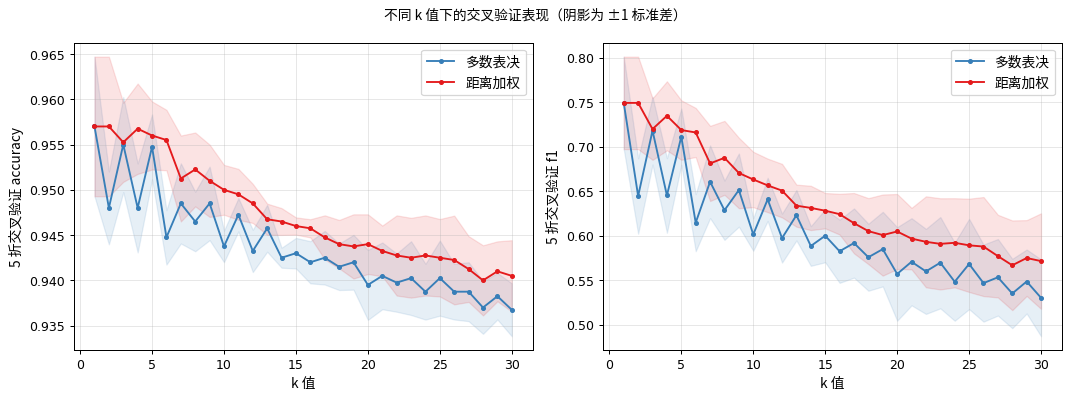

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"uniform": "#377eb8", "distance": "#e41a1c"}
names = {"uniform": "多数表决", "distance": "距离加权"}
for ax, metric in zip(axes, ("accuracy", "f1")):
    for w in ("uniform", "distance"):
        mean, std = cv_results[(w, metric)]
        ax.plot(k_values, mean, marker="o", ms=3, color=colors[w], label=names[w])
        ax.fill_between(k_values, mean - std, mean + std, color=colors[w], alpha=0.12)
    ax.set_xlabel("k 值", fontproperties=fontProps)
    ax.set_ylabel(f"5 折交叉验证 {metric}", fontproperties=fontProps)
    ax.grid(alpha=0.3)
    ax.legend(prop=fontProps)
fig.suptitle("不同 k 值下的交叉验证表现（阴影为 ±1 标准差）", fontproperties=fontProps)
plt.tight_layout()
plt.show()

注意：多数表决在 k 为偶数时容易出现平票（二分类 2:2），平票时 argmax 取类别 0，因此偶数 k 的召回率偏低，曲线呈锯齿状；
距离加权几乎不会平票，曲线更平滑。二分类用多数表决时一般取奇数 k。

### 用"一倍标准误"原则确定超参数

这个数据集上 CV F1 最高的是 k=1，但 k=1 只看最近的一个点，对噪声最敏感，而且 `predict_proba` 只能输出 0 或 1。
从曲线看 k=1~4 的差距远小于折间波动，并不显著。

常用的 **一倍标准误（one-standard-error）原则**：先找到 CV 最优分数 $s^*$ 及其标准误 $SE = \sigma / \sqrt{K}$，
然后在所有 CV 分数 $\ge s^* - SE$ 的候选中选**最简单**的模型。对 KNN 来说 k 越大模型越简单（决策边界越平滑）。
以 F1 为标准（兼顾精确率和召回率），在两种表决方式、所有 k 中统一挑选。

In [14]:
n_folds = 5
candidates = [(w, k, cv_results[(w, "f1")][0][j], cv_results[(w, "f1")][1][j])
              for w in ("uniform", "distance") for j, k in enumerate(k_values)]
w_star, k_star, s_star, std_star = max(candidates, key=lambda t: t[2])
se = std_star / np.sqrt(n_folds)
print(f"CV 最优: weights = {w_star}, k = {k_star}, F1 = {s_star:.4f}, SE = {se:.4f}")
print(f"阈值 s* - SE = {s_star - se:.4f}")

ok = [c for c in candidates if c[2] >= s_star - se]
best_weights, best_k, best_cv_f1, _ = max(ok, key=lambda t: t[1])  # 取 k 最大的
print(f"一倍标准误原则选定: weights = {best_weights}, k = {best_k} (CV F1 = {best_cv_f1:.4f})")

CV 最优: weights = uniform, k = 1, F1 = 0.7492, SE = 0.0232
阈值 s* - SE = 0.7260
一倍标准误原则选定: weights = distance, k = 4 (CV F1 = 0.7347)


### 在测试集上做最终评估

用选定的超参数在**完整训练集**上重新拟合，测试集只在这里用一次。

In [15]:
final_model = KNNClassifier(k=best_k, weights=best_weights).fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

for name, val in classification_metrics(y_test, y_pred_final).items():
    print(f"{name:>9}: {val:.4f}")
print("混淆矩阵 [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_test, y_pred_final))

 accuracy: 0.9690
precision: 0.9710
   recall: 0.6979
       f1: 0.8121
混淆矩阵 [[TN, FP], [FN, TP]]:
[[902   2]
 [ 29  67]]


### 调整分类阈值

`predict` 默认按"票数过半"判正类，相当于阈值 0.5。正类稀少时，降低阈值可以用一些精确率换取更高召回率（比如银行更在意不漏掉潜在的贷款客户）。

注意：正式使用时阈值也应该在交叉验证中选，这里直接在测试集上扫描只是为了展示精确率与召回率的取舍。

In [16]:
proba = final_model.predict_proba(X_test)[:, 1]
print(f"{'阈值':>6} {'精确率':>8} {'召回率':>8} {'F1':>8}")
for thr in (0.2, 0.3, 0.4, 0.5, 0.6):
    m = classification_metrics(y_test, (proba >= thr).astype(int))
    print(f"{thr:>8.1f} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1']:>8.4f}")

    阈值      精确率      召回率       F1
     0.2     0.7434     0.8750   0.8038
     0.3     0.8977     0.8229   0.8587
     0.4     0.9268     0.7917   0.8539
     0.5     0.9710     0.6979   0.8121
     0.6     0.9828     0.5938   0.7403


### 二维决策边界可视化

只取 Income 和 CCAvg 两个特征，直观看 k 对决策边界的影响：k=1 时边界支离破碎（过拟合），k 增大后边界变平滑，k 过大时少数类区域被"吞掉"。

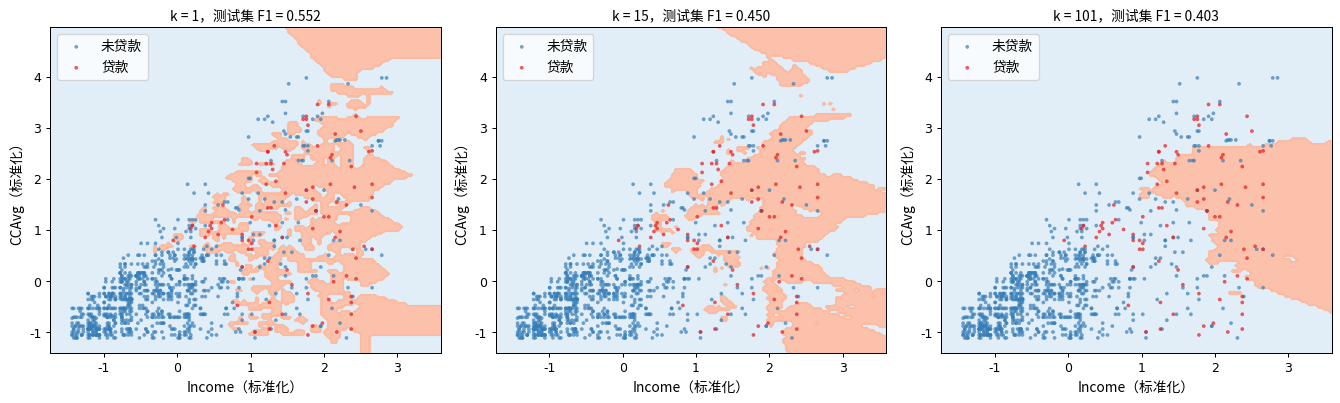

In [17]:
f_idx = [feature_names.index("Income"), feature_names.index("CCAvg")]
X2_train, X2_test = X_train[:, f_idx], X_test[:, f_idx]

x_min, x_max = X2_train[:, 0].min() - 0.3, X2_train[:, 0].max() + 0.3
y_min, y_max = X2_train[:, 1].min() - 0.3, X2_train[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 120), np.linspace(y_min, y_max, 120))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
bg = ListedColormap(["#deebf7", "#fcbba1"])
for ax, k in zip(axes, (1, 15, 101)):
    model = KNNClassifier(k=k).fit(X2_train, y_train)
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=bg, alpha=0.9)
    for c, color, label in ((0, "#377eb8", "未贷款"), (1, "#e41a1c", "贷款")):
        m = y_test == c
        ax.scatter(X2_test[m, 0], X2_test[m, 1], s=9, c=color, alpha=0.7, label=label, edgecolors="none")
    f1 = classification_metrics(y_test, model.predict(X2_test))["f1"]
    ax.set_title(f"k = {k}，测试集 F1 = {f1:.3f}", fontproperties=fontProps)
    ax.set_xlabel("Income（标准化）", fontproperties=fontProps)
    ax.set_ylabel("CCAvg（标准化）", fontproperties=fontProps)
    ax.legend(prop=fontProps, loc="upper left")
plt.tight_layout()
plt.show()